# The value network, opened up

The page ships a neural network of 15,265 parameters that judges billiards
positions. It has never been told how to aim, what a cushion is, or which way
up a table goes. It answers one question — *you are about to shoot, here is the
table, how often does this end with you winning?* — and the player is built
around that answer.

This notebook opens the weights that are actually in the repository, runs them,
and looks at what they do.

It needs **numpy**, **matplotlib** and **node**. No tensorflow: the model file
is a JSON description and a flat block of float32, so a forward pass through it
is four lines of numpy. Node is here for the opposite reason — the rules, the
physics and the feature encoder are JavaScript, and there must be exactly one
definition of those, not a second one written out again in Python.

`NETWORK.md` is the reference for everything below.

In [1]:
import json, os, subprocess, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
assert os.path.exists(os.path.join(ROOT, 'train', 'encode.js')), ROOT

def node(*args, timeout=1800):
    '''Run one of the repo's own tools and parse the json it prints.'''
    out = subprocess.run(['node'] + list(args), cwd=ROOT, capture_output=True,
                         text=True, timeout=timeout)
    if out.returncode != 0:
        raise RuntimeError(out.stderr[-2000:])
    return json.loads(out.stdout)

# --- chart style -----------------------------------------------------------
# One categorical order, used in that order and never cycled; a single blue
# ramp where the quantity is a magnitude; blue-to-red through a neutral grey
# where it is a polarity with a meaningful zero.
BLUE, ORANGE, INK, INK2, MUTED = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#8b8a85'
SURFACE, GRID, CLOTH = '#fcfcfb', '#e6e5e1', '#dcdfd8'
SEQ = LinearSegmentedColormap.from_list('seq', ['#cde2fb', '#2a78d6', '#0d366b'])
DIV = LinearSegmentedColormap.from_list('div', ['#e34948', '#f0efec', '#2a78d6'])

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'figure.dpi': 110, 'font.size': 10,
    'text.color': INK, 'axes.labelcolor': INK2, 'axes.edgecolor': GRID,
    'xtick.color': INK2, 'ytick.color': INK2, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.titlepad': 10, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.axisbelow': True, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'legend.frameon': False, 'lines.linewidth': 2, 'lines.markersize': 7,
})
print('repo:', ROOT)

repo: /home/user/billard_js


## 1. What is in the model file

`model/value/` is what `tf.loadLayersModel` expects and nothing more: a
`model.json` describing the topology, and a `weights.bin` holding every
parameter as little-endian float32, concatenated in the order the manifest
lists them. That is a format numpy can read without help.

In [2]:
MODEL = os.path.join(ROOT, 'model', 'value')
manifest = json.load(open(os.path.join(MODEL, 'model.json')))
raw = np.fromfile(os.path.join(MODEL, 'weights.bin'), dtype='<f4')

W, at = {}, 0
for spec in manifest['weightsManifest'][0]['weights']:
    n = int(np.prod(spec['shape']))
    W[spec['name']] = raw[at:at + n].reshape(spec['shape'])
    at += n
assert at == raw.size, 'the manifest and the weights file disagree'

print(f"{'layer':16}{'shape':>13}{'activation':>13}{'parameters':>12}")
total = 0
for L in manifest['modelTopology']['config']['layers']:
    c = L['config']
    k = W[c['name'] + '/kernel']
    n = k.size + W[c['name'] + '/bias'].size
    total += n
    print(f"{c['name']:16}{str(k.shape):>13}{c['activation']:>13}{n:>12,}")
print(f"\n{total:,} parameters, {os.path.getsize(os.path.join(MODEL, 'weights.bin'))/1024:.0f} KB on disk")

layer                   shape   activation  parameters
dense_Dense1        (109, 96)         relu      10,560
dense_Dense2         (96, 48)         relu       4,656
dense_Dense3          (48, 1)         tanh          49

15,265 parameters, 60 KB on disk


Two relu layers and a tanh — `tanh` because the thing being predicted is a win
or a loss and nothing outside ±1 means anything. That is the entire model.
Everything else in this notebook is about what to feed it and what the answer
means.

In [3]:
def value(x):
    '''Positions in (n, 109), values out in (n,). +1 is a win for the player about to shoot.'''
    h = np.maximum(0, x @ W['dense_Dense1/kernel'] + W['dense_Dense1/bias'])
    h = np.maximum(0, h @ W['dense_Dense2/kernel'] + W['dense_Dense2/bias'])
    return np.tanh(h @ W['dense_Dense3/kernel'] + W['dense_Dense3/bias']).ravel()

## 2. What a position looks like to it

`train/encode.js` is the only definition of that, so we ask it rather than
writing it out again here. `train/dump.js turns` plays a few racks and hands
back every turn in them: 109 features, the outcome of the rack as ±1, and how
many turns from the end it was.

In [4]:
sample = node('train/dump.js', 'turns', '--games', '3', '--seed', '5')
labels = sample['labels']
X = np.array([r['x'] for r in sample['rows']], dtype=np.float32)
print(f"{len(sample['rows'])} turns from {sample['racks']} racks, {X.shape[1]} features each")

GROUPS = [('mine grid', 0, 32), ('theirs grid', 32, 64), ('eight grid', 64, 96),
          ('cue ball', 96, 99), ('the game', 99, 104), ('the shortlist', 104, 109)]
for name, a, b in GROUPS:
    shown = ', '.join(labels[a:min(b, a + 3)])
    print(f'  {name:15}{b - a:>3}  {shown}{" ..." if b - a > 3 else ""}')

44 turns from 3 racks, 109 features each
  mine grid       32  mine[0,0], mine[0,1], mine[0,2] ...
  theirs grid     32  theirs[0,0], theirs[0,1], theirs[0,2] ...
  eight grid      32  eight[0,0], eight[0,1], eight[0,2] ...
  cue ball         3  cue.x, cue.y, cue.inHand
  the game         5  mineLeft, theirsLeft, open ...
  the shortlist    5  shots, bestCut, bestDistance ...


Three of those groups are an 8×4 occupancy grid — one channel for my balls, one
for theirs, one for the 8 — and the rest are sixteen scalars.

The grid is deliberately coarse. Its job is the *shape* of the table: spread
out or stacked in a corner, where the 8 sits relative to both halves. Whether a
pot is actually on is said exactly by the five shortlist features, which
`geometry.js` computed anyway and handed over for free.

Everything is written from the point of view of whoever is about to shoot —
*mine* and *theirs*, never player 1 and player 2 — and nothing is identified by
ball number, because the 3 and the 5 play identically and telling them apart
would only let a network memorise racks.

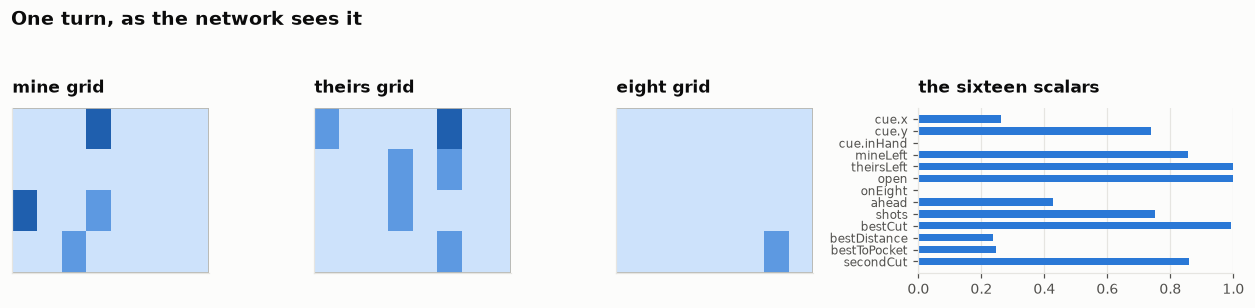

this turn: 6 pots on, straightest at 7° of cut, and it was turn 18 from the end of its rack


In [5]:
# a turn from the middle of a rack rather than the break: something is on
pick = int(np.flatnonzero((X[:, labels.index('shots')] > 0) &
                          (X[:, labels.index('cue.inHand')] == 0))[0])
row = X[pick]

fig, axes = plt.subplots(1, 4, figsize=(11.5, 2.6), width_ratios=[1, 1, 1, 1.6])
for ax, (name, a, b) in zip(axes, GROUPS[:3]):
    ax.imshow(row[a:b].reshape(8, 4).T, cmap=SEQ, vmin=0, vmax=1,
              extent=(0, 8, 4, 0), aspect='auto')
    ax.add_patch(plt.Rectangle((0, 0), 8, 4, fill=False, edgecolor='#b9b8b2', lw=1.2))
    ax.set_title(name, color=INK)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

ax = axes[3]
names = labels[96:109]
ax.barh(range(len(names)), row[96:109], color=BLUE, height=0.62)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis(); ax.set_xlim(0, 1)
ax.set_title('the sixteen scalars', color=INK)
ax.grid(axis='y', visible=False)

fig.suptitle('One turn, as the network sees it', x=0.012, ha='left', fontsize=12.5,
             weight='bold', y=1.06)
fig.tight_layout(); plt.show()

print(f'this turn: {row[labels.index("shots")] * 8:.0f} pots on, straightest at '
      f'{np.degrees(np.arccos(row[labels.index("bestCut")])):.0f}° of cut, '
      f'and it was turn {int(sample["rows"][pick]["ply"])} from the end of its rack')

### Checking the imitation against the real thing

The forward pass above is numpy's; the game's is tensorflow.js. If the two ever
disagreed, everything below would be fiction. `train/dump.js predict` puts the
same rows through the real model — when tfjs is installed, which it is not
unless you have run `npm install`.

In [6]:
try:
    with tempfile.NamedTemporaryFile('w', suffix='.json', delete=False) as f:
        json.dump(X[:64].tolist(), f)
        path = f.name
    real = np.array(node('train/dump.js', 'predict', '--file', path)['values'])
    print(f'largest disagreement over 64 positions: {np.abs(real - value(X[:64])).max():.2e}')
    os.unlink(path)
except Exception as err:
    print('skipped — tensorflow.js is not installed here (npm install):', err)

largest disagreement over 64 positions: 5.96e-08


## 3. Does it actually know anything?

The only honest test is on racks the model was never fitted to.

`train/value.js` splits **by rack, not by turn** — every turn in a rack carries
the same label and they all look much alike, so splitting by turn puts near
copies of the same position on both sides of the fence and reports a score that
means nothing. The shuffle is seeded, so the split is reproducible, and the few
lines below reproduce it exactly: the same 12% of racks the training run held
back, down to the row.

If `data/` is not here — it is not in the repository, since a few hours of self
play is tens of megabytes and none of it is source — this collects a fresh
batch instead, which is unseen by construction.

In [7]:
STRIDE = 111                      # 109 features, then the label and the ply

def load_shards(d):
    meta = json.load(open(os.path.join(d, 'meta.json')))
    return meta, np.concatenate([
        np.fromfile(os.path.join(d, s), dtype='<f4').reshape(-1, STRIDE)
        for s in meta['shards']])

def held_back(rows, fraction=0.12, seed=7):
    '''The rows train/value.js would have kept back, by the same seeded shuffle.'''
    ply = rows[:, 110]
    starts = np.flatnonzero(np.r_[True, ply[1:] != ply[:-1] - 1])   # ply stops counting down
    ends = np.r_[starts[1:], len(rows)]

    order, x = list(range(len(starts))), seed
    for i in range(len(order) - 1, 0, -1):
        x = int(float(x) * 1103515245.0 + 12345.0) & 0x7fffffff     # the same lcg, in doubles
        j = x % (i + 1)
        order[i], order[j] = order[j], order[i]

    kept = order[int(len(order) * (1 - fraction)):]
    return np.concatenate([np.arange(starts[r], ends[r]) for r in kept]), len(order)

trained_on = [os.path.join(ROOT, 'data', d) for d in ('v1', 'v2')]
if all(os.path.exists(os.path.join(d, 'meta.json')) for d in trained_on):
    metas, parts = zip(*[load_shards(d) for d in trained_on])
    rows = np.concatenate(parts)
    for d, m in zip(trained_on, metas):
        print(f"{os.path.basename(d)}: {m['turns']:>7,} turns from {m['racks']:>5,} racks"
              f" of {m.get('player') or 'the baseline bot'}")
    keep, racks = held_back(rows)
    print(f'\n{len(rows):,} turns from {racks:,} racks; {len(keep):,} held back')
    rows = rows[keep]
else:
    out = os.path.join(ROOT, 'data', 'notebook')
    print('no collected data here — playing 60 fresh racks, a couple of minutes ...')
    subprocess.run(['node', 'train/collect.js', '--games', '60', '--out', out],
                   cwd=ROOT, check=True)
    meta, rows = load_shards(out)
    print(f"\n{meta['turns']:,} fresh turns from {meta['racks']:,} racks, none of them trained on")

F, y, ply = rows[:, :109], rows[:, 109], rows[:, 110]
v = value(F)
print(f'\nmse         {np.mean((v - y) ** 2):.4f}')
print(f'a constant  {np.mean((y.mean() - y) ** 2):.4f}   (always guessing {y.mean():+.3f})')
print(f'sign right  {np.mean(np.sign(v) == np.sign(y)) * 100:.1f}%   (a coin toss is 50%)')

v1:  69,984 turns from 3,000 racks of the baseline bot
v2:  36,348 turns from 2,397 racks of model/value

106,332 turns from 5,397 racks; 12,637 held back

mse         0.9535
a constant  0.9945   (always guessing +0.074)
sign right  58.4%   (a coin toss is 50%)


About four hundredths of mean squared error over guessing the average, and
eight points of accuracy over a coin toss. That is a thin margin and the right
size: most billiards positions genuinely are close, and a model that scored far
better here would be telling you it had found something about the *data* — the
rack order, the bot's habits — rather than something about the game.

Where the margin sits is the part worth looking at.

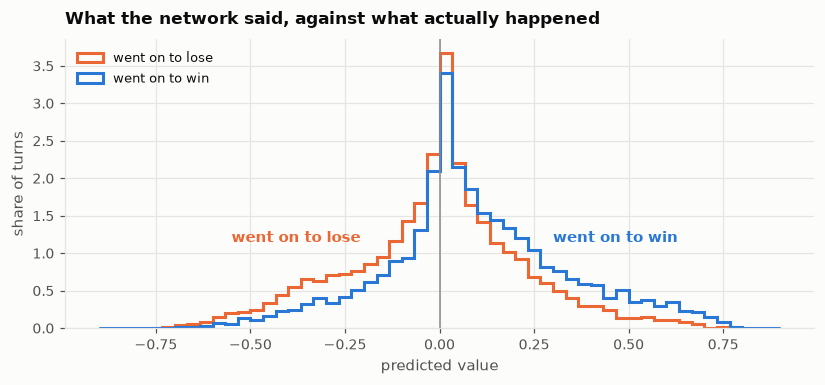

median when the shooter went on to win:  +0.063
median when the shooter went on to lose: +0.007


In [8]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
bins = np.linspace(-0.9, 0.9, 55)
for label, mask, colour in [('went on to lose', y < 0, ORANGE), ('went on to win', y > 0, BLUE)]:
    ax.hist(v[mask], bins=bins, density=True, histtype='step', lw=2, color=colour, label=label)
ax.axvline(0, color=MUTED, lw=1)
ax.annotate('went on to lose', (-0.55, 1.15), color=ORANGE, weight='bold', fontsize=9.5)
ax.annotate('went on to win', (0.30, 1.15), color=BLUE, weight='bold', fontsize=9.5)
ax.set_title('What the network said, against what actually happened')
ax.set_xlabel('predicted value'); ax.set_ylabel('share of turns')
ax.legend(loc='upper left', fontsize=8.5)
fig.tight_layout(); plt.show()

print(f'median when the shooter went on to win:  {np.median(v[y > 0]):+.3f}')
print(f'median when the shooter went on to lose: {np.median(v[y < 0]):+.3f}')

Two overlapping humps, both centred near zero, the blue one pushed right. That
is what an 8% edge looks like — and it is an edge on *every* turn, including
the ones nobody could call.

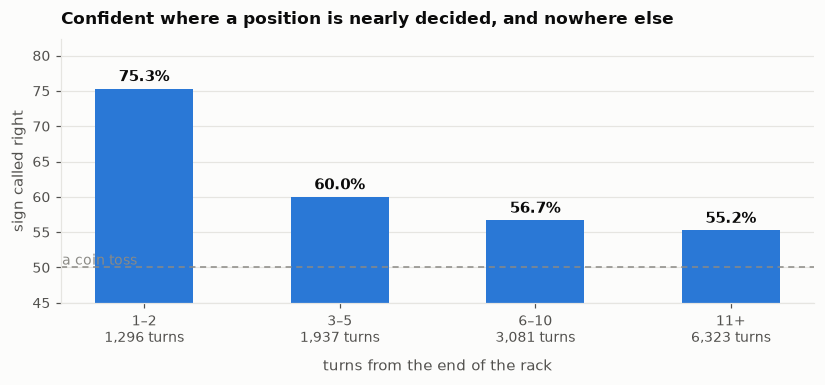

In [9]:
buckets = [(1, 2, '1–2'), (3, 5, '3–5'), (6, 10, '6–10'), (11, 999, '11+')]
acc, ns = [], []
for lo, hi, _ in buckets:
    m = (ply >= lo) & (ply <= hi)
    acc.append(np.mean(np.sign(v[m]) == np.sign(y[m])) * 100)
    ns.append(int(m.sum()))

fig, ax = plt.subplots(figsize=(7.6, 3.6))
bars = ax.bar([b[2] for b in buckets], acc, color=BLUE, width=0.5)
ax.axhline(50, color=MUTED, lw=1, ls=(0, (4, 3)))
ax.annotate('a coin toss', (-0.42, 50.4), color=MUTED, fontsize=9)
for bar, a in zip(bars, acc):
    ax.annotate(f'{a:.1f}%', (bar.get_x() + bar.get_width() / 2, a), xytext=(0, 5),
                textcoords='offset points', ha='center', color=INK, weight='bold')
ax.set_xticks(range(len(buckets)))
ax.set_xticklabels([f'{b[2]}\n{n:,} turns' for b, n in zip(buckets, ns)])
ax.set_ylim(45, max(acc) + 7); ax.set_ylabel('sign called right')
ax.set_xlabel('turns from the end of the rack', labelpad=8)
ax.set_title('Confident where a position is nearly decided, and nowhere else')
ax.grid(axis='x', visible=False)
fig.tight_layout(); plt.show()

That shape is the whole point. One or two shots from the end the rack is nearly
decided and the model can see it; at the break it is close to a coin toss and
the model says so. **A flat line at 58% would be a worse model with the same
average score** — it would mean it had learned something that is not in the
game.

Is the number itself meaningful, or only its sign? Bin the predictions into
deciles and ask how often each decile actually won.

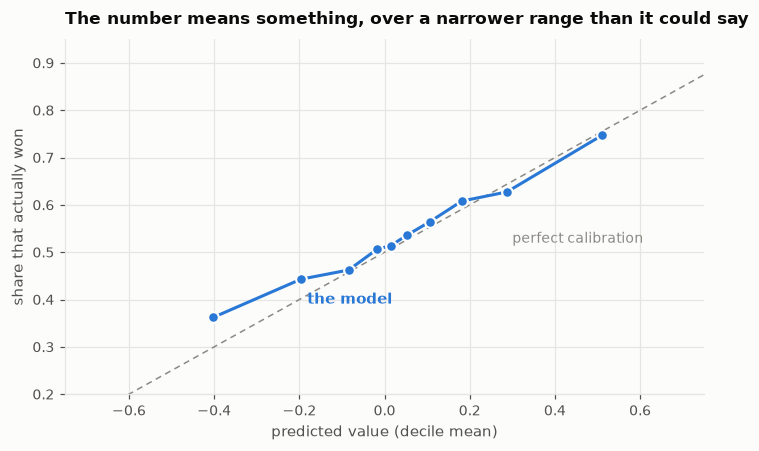

it only ever says between -0.77 and +0.78; deciles run -0.40 to +0.51,
and those two deciles won 36% and 75% of the time


In [10]:
edges = np.quantile(v, np.linspace(0, 1, 11))
edges[0], edges[-1] = -1.001, 1.001
idx = np.clip(np.digitize(v, edges) - 1, 0, 9)
mid = np.array([v[idx == b].mean() for b in range(10)])
rate = np.array([(y[idx == b] > 0).mean() for b in range(10)])

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.plot([-1, 1], [0, 1], color=MUTED, lw=1, ls=(0, (4, 3)), zorder=1)
ax.plot(mid, rate, color=BLUE, marker='o', markeredgecolor=SURFACE, markeredgewidth=1.4, zorder=2)
ax.annotate('perfect calibration', (0.30, 0.52), color=MUTED, fontsize=9)
ax.annotate('the model', (mid[1], rate[1]), xytext=(4, -16), textcoords='offset points',
            color=BLUE, weight='bold', fontsize=9.5)
ax.set_xlim(-0.75, 0.75); ax.set_ylim(0.2, 0.95)
ax.set_xlabel('predicted value (decile mean)'); ax.set_ylabel('share that actually won')
ax.set_title('The number means something, over a narrower range than it could say')
fig.tight_layout(); plt.show()

print(f'it only ever says between {v.min():+.2f} and {v.max():+.2f}; '
      f'deciles run {mid[0]:+.2f} to {mid[-1]:+.2f},')
print(f'and those two deciles won {rate[0] * 100:.0f}% and {rate[-1] * 100:.0f}% of the time')

It tracks the diagonal closely across the range it actually uses, and is a
little kind to the positions it likes least — a decile it scores at −0.4,
meaning about a 30% chance, won rather more often than that. The range itself
is narrow: squared error against ±1 labels on a noisy game pulls every
prediction towards the middle, so the model never says ±1 even when a rack is
over bar the shouting.

None of that matters much to the player, which only ever compares two
positions with each other. Monotonic is what it needs; calibrated is a bonus.

## 4. "Where would you like the cue ball?"

This is the question the player actually asks. `train/dump.js sweep` stops a
real rack partway through and encodes the same table once for every legal
cue-ball spot on a grid, so we can ask it everywhere at once instead of at the
two or three places a shot could leave it.

Nothing about this map was taught. The network was only ever shown positions
and outcomes.

In [11]:
sweep = node('train/dump.js', 'sweep', '--seed', '12', '--at', '16', '--steps', '48')
t = sweep['table']
legal = [c for c in sweep['cells'] if c['legal']]
vals = value(np.array([c['x_'] for c in legal], dtype=np.float32))

heat = np.full((sweep['down'], sweep['across']), np.nan)
for c, val in zip(legal, vals):
    heat[c['j'], c['i']] = val

mine = t['groups'][t['player']]
up = [b for b in t['balls'] if b['id'] != 0]
print(f"turn {sweep['turn']} of rack {sweep['seed']}: player {t['player'] + 1} is on "
      f"{mine}, {len(up)} balls up")
print(f'best spot {vals.max():+.3f}, worst {vals.min():+.3f} — '
      f'{"the same table is won or lost on where the cue ball sits" if vals.min() < 0 < vals.max() else "every spot the same side of even"}')

turn 16 of rack 12: player 2 is on stripes, 3 balls up
best spot +0.299, worst -0.058 — the same table is won or lost on where the cue ball sits


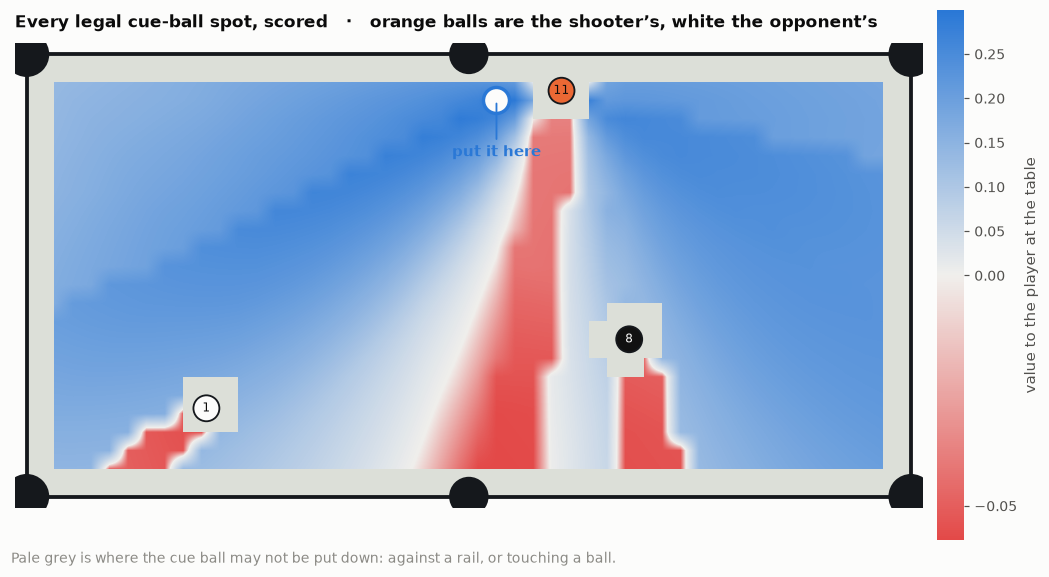

In [12]:
fig, ax = plt.subplots(figsize=(9.6, 5.2))
cmap = DIV.copy() if vals.min() < 0 < vals.max() else SEQ.copy()
norm = (TwoSlopeNorm(vcenter=0, vmin=float(vals.min()), vmax=float(vals.max()))
        if vals.min() < 0 < vals.max() else None)
cmap.set_bad(CLOTH)                       # spots the cue ball may not be put on

im = ax.imshow(heat, cmap=cmap, norm=norm, origin='upper', aspect='equal',
               extent=(0, t['width'], t['height'], 0), interpolation='bilinear',
               vmin=None if norm else float(vals.min()), vmax=None if norm else float(vals.max()))

for p in t['pockets']:
    ax.add_patch(plt.Circle((p['x'], p['y']), p['radius'], facecolor='#15181c', zorder=3))
for b in up:
    face = '#111111' if b['id'] == 8 else (ORANGE if b['group'] == mine else SURFACE)
    ax.add_patch(plt.Circle((b['x'], b['y']), t['radius'] * 1.15, facecolor=face,
                            edgecolor='#15181c', lw=1.2, zorder=4))
    ax.annotate(str(b['id']), (b['x'], b['y']), color=SURFACE if b['id'] == 8 else INK,
                fontsize=8, ha='center', va='center', zorder=5)

best = legal[int(np.argmax(vals))]
ax.add_patch(plt.Circle((best['x'], best['y']), t['radius'] * 1.15, facecolor=SURFACE,
                        edgecolor=BLUE, lw=2.2, zorder=6))
# the y axis is inverted, so a spot near the top of the screen wants its
# label below it: negative offset points, not positive
away = -34 if best['y'] < t['height'] / 2 else 34
ax.annotate('put it here', (best['x'], best['y']), xytext=(0, away), ha='center',
            va='center', textcoords='offset points', color=BLUE, weight='bold',
            fontsize=9.5, arrowprops=dict(arrowstyle='-', color=BLUE, lw=1.2), zorder=7)

ax.add_patch(plt.Rectangle((0, 0), t['width'], t['height'], fill=False,
                           edgecolor='#15181c', lw=2.5, zorder=2))
ax.set_xlim(-0.03, t['width'] + 0.03); ax.set_ylim(t['height'] + 0.03, -0.03)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title('Every legal cue-ball spot, scored   ·   orange balls are the shooter’s, '
             'white the opponent’s')
bar = fig.colorbar(im, ax=ax, fraction=0.028, pad=0.015)
bar.set_label('value to the player at the table', color=INK2)
bar.outline.set_visible(False)
fig.text(0.012, -0.01, 'Pale grey is where the cue ball may not be put down: against a '
         'rail, or touching a ball.', color=MUTED, fontsize=9)
fig.tight_layout(); plt.show()

The map is mostly the shortlist features talking: blue is where a pot is on and
straight, red is where the shooter is snookered or left with a thin cut. The
network is not doing the geometry — it is handed the geometry and has learned
what it is worth, which is the division of labour the whole design rests on.

## 5. What is it looking at?

The crude measure: how much weight leaves each input on its way into the first
layer, scaled by how much that input actually varies in real play. A feature
the first layer barely touches, or that never moves, cannot matter much. It is
a proxy for attention, not a measure of importance.

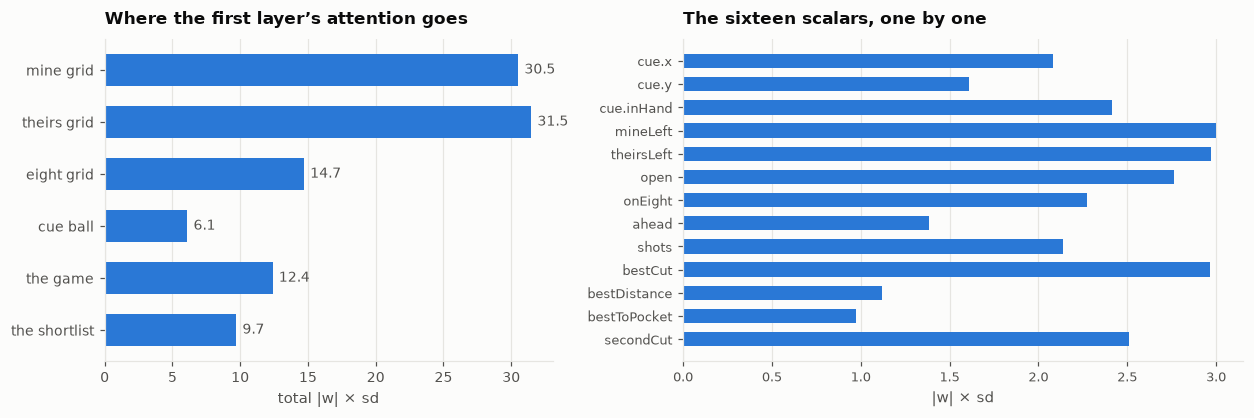

per input, the scalars pull far harder than the grid does:
  grid       76.7 over 96 inputs  =  0.80 each
  scalars    28.2 over 13 inputs  =  2.17 each


In [13]:
pull = np.abs(W['dense_Dense1/kernel']).sum(axis=1) * F.std(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.9), width_ratios=[1, 1.25])
names = [g[0] for g in GROUPS]
totals = [pull[a:b].sum() for _, a, b in GROUPS]
ax1.barh(names, totals, color=BLUE, height=0.62)
ax1.invert_yaxis(); ax1.grid(axis='y', visible=False)
ax1.set_title('Where the first layer’s attention goes'); ax1.set_xlabel('total |w| × sd')
for i, tot in enumerate(totals):
    ax1.annotate(f'{tot:.1f}', (tot, i), xytext=(4, 0), textcoords='offset points',
                 va='center', color=INK2, fontsize=9)

tail = list(range(96, 109))
ax2.barh([labels[i] for i in tail], pull[tail], color=BLUE, height=0.62)
ax2.invert_yaxis(); ax2.grid(axis='y', visible=False)
ax2.set_title('The sixteen scalars, one by one'); ax2.set_xlabel('|w| × sd')
ax2.tick_params(labelsize=8.5)
fig.tight_layout(); plt.show()

print('per input, the scalars pull far harder than the grid does:')
print(f'  grid     {sum(totals[:3]):6.1f} over 96 inputs  =  {sum(totals[:3]) / 96:.2f} each')
print(f'  scalars  {sum(totals[3:]):6.1f} over 13 inputs  =  {sum(totals[3:]) / 13:.2f} each')

The better question is counterfactual: take real positions, change one thing,
and see what the answer does. That is exactly what the search does when it
judges a shot it has not played — these are not tables that occurred, they are
tables asked about.

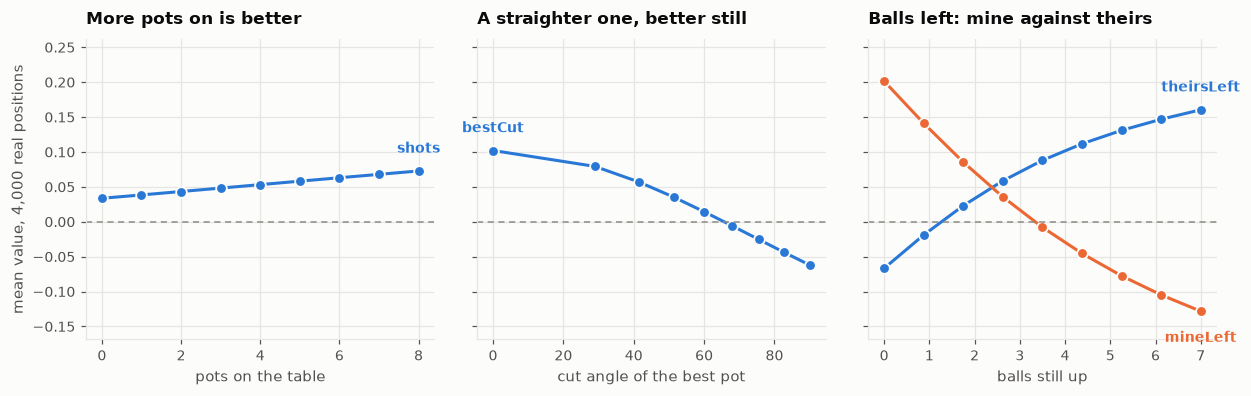

In [14]:
sub = F[np.random.default_rng(4).choice(len(F), size=min(4000, len(F)), replace=False)].copy()

def holding(name, values):
    '''Mean value over those positions with one feature forced to each value in turn.'''
    i = labels.index(name)
    return np.array([value(np.where(np.arange(109) == i, v, sub)).mean() for v in values])

steps = np.linspace(0, 1, 9)
panels = [
    ('More pots on is better', steps * 8, 'pots on the table',
     [('shots', holding('shots', steps), BLUE)]),
    ('A straighter one, better still', np.degrees(np.arccos(steps)), 'cut angle of the best pot',
     [('bestCut', holding('bestCut', steps), BLUE)]),
    ('Balls left: mine against theirs', steps * 7, 'balls still up',
     [('theirsLeft', holding('theirsLeft', steps), BLUE),
      ('mineLeft', holding('mineLeft', steps), ORANGE)]),
]
lo = min(s[1].min() for _, _, _, ss in panels for s in ss)
hi = max(s[1].max() for _, _, _, ss in panels for s in ss)

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.7), sharey=True)
for ax, (title, xs, xlabel, series) in zip(axes, panels):
    for name, ys, colour in series:
        ax.plot(xs, ys, color=colour, marker='o', markeredgecolor=SURFACE, markeredgewidth=1.2)
        # label the end of the curve that is furthest from the other one
        end = int(np.argmax(ys)) if colour == BLUE else int(np.argmin(ys))
        ax.annotate(name, (xs[end], ys[end]),
                    xytext=(0, 12 if colour == BLUE else -20),
                    textcoords='offset points', ha='center', color=colour,
                    weight='bold', fontsize=9)
    ax.axhline(0, color=MUTED, lw=1, ls=(0, (4, 3)))
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.set_ylim(lo - 0.04, hi + 0.06)
axes[0].set_ylabel('mean value, 4,000 real positions')
fig.tight_layout(); plt.show()

In [15]:
def worth(name):
    off, on = sub.copy(), sub.copy()
    off[:, labels.index(name)] = 0
    on[:, labels.index(name)] = 1
    return value(on) - value(off)

hand = worth('cue.inHand')
print(f'ball in hand is worth {hand.mean():+.3f} on average, '
      f'and between {hand.min():+.3f} and {hand.max():+.3f}')
print(f'being on the 8 rather than on your group: {worth("onEight").mean():+.3f}')
print(f'a second, dead straight pot as well:      {worth("secondCut").mean():+.3f}')

ball in hand is worth +0.146 on average, and between -0.059 and +0.532
being on the 8 rather than on your group: +0.087
a second, dead straight pot as well:      -0.006


Ball in hand is worth more than anything else one number can change about a
position, which is the right answer and one nobody put there: it is in the
weights because the games it learned from were won and lost that way.

The second pot being worth nothing is the surprise, and probably an honest one
— by the time a second pot is on, `shots` has already said so, and what the
*second* one looks like barely moves a rack's outcome.

## What this is not

The network never aims, never picks a shot, and has no idea what a cushion is.
It scores a table; `train/player.js` does the rest — shortlist the pots,
simulate each one several ways, score what each leaves, take the best.

The expensive lesson of the project was that the *search's* action space, not
the network's judgement, was what limited the player. Giving it nine ways to
play each pot instead of one moved it further than a second round of training
ever did. Both sides of that are written up in `README.md`.

To retrain it from nothing:

```bash
npm install                                 # tfjs, and only for the training tools
node train/collect.js --games 3000 --search 0 --out data/v1
node train/value.js   --data data/v1 --out model/value
node train/collect.js --games 2400 --out data/v2 --player model/value --explore 0.15
node train/value.js   --data data/v1,data/v2 --out model/value --width 96
node train/selfplay.js --games 30 --a value:model/value --b search4
```